# Decision Tree

In [1]:
import sys 
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [11]:
%reload_ext autoreload
%autoreload 2
# misc imports
import numpy as np
import matplotlib.pyplot as plt
from time import perf_counter
import pandas as pd

# sklearn imports
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier as SklearnDecisionTreeClassifier

# own imports
from models.decision_tree import DecisionTree
from utils.plots import (
    plot_confusion_matrix,
    plot_difference_loss,
    plot_decision_boundary,
)
from utils.torch import TorchModelWrapper
from metrics.classification import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
from utils.tests import (
    parameter_sweep_trees
)

## Dataset

### Generation and Split

In [3]:
X, y = make_moons(
    n_samples=1000,
    noise=0.25,
    random_state=42,
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

### Plotting

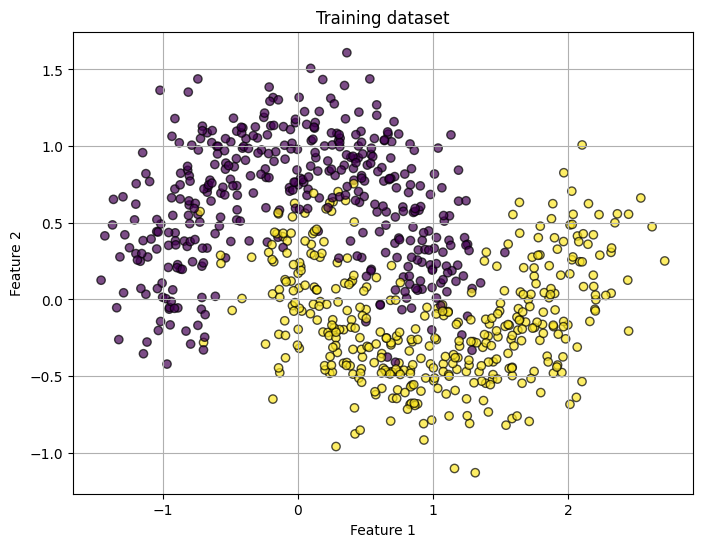

In [4]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_train,
    alpha=0.7,
    edgecolor="k",
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Training dataset")
plt.grid(True)

plt.show()

## Comparison with `sklearn` model

In [8]:
# Scratch Model
scratch_tree = DecisionTree(
    max_depth=3,
    min_samples_split=2,
    random_state=42,
)

start = perf_counter()
scratch_tree.fit(X_train, y_train)
scratch_fit_time = perf_counter() - start

start = perf_counter()
scratch_preds = scratch_tree.predict(X_test)
scratch_predict_time = perf_counter() - start

# Sklearn Model
sklearn_tree = SklearnDecisionTreeClassifier(
    criterion="entropy", # we are using information gain as the criterion for fair comparison with the scratch model
    max_depth=3,
    min_samples_split=2,
    random_state=42,
)

start = perf_counter()
sklearn_tree.fit(X_train, y_train)
sklearn_fit_time = perf_counter() - start

start = perf_counter()
sklearn_preds = sklearn_tree.predict(X_test)
sklearn_predict_time = perf_counter() - start

In [9]:
results = {
    "From scratch": {
        "Accuracy": accuracy_score(y_test, scratch_preds),
        "Precision": precision_score(y_test, scratch_preds),
        "Recall": recall_score(y_test, scratch_preds),
        "F1": f1_score(y_test, scratch_preds),
        "Fit time": scratch_fit_time,
        "Predict time": scratch_predict_time,
    },
    "Scikit-learn": {
        "Accuracy": accuracy_score(y_test, sklearn_preds),
        "Precision": precision_score(y_test, sklearn_preds),
        "Recall": recall_score(y_test, sklearn_preds),
        "F1": f1_score(y_test, sklearn_preds),
        "Fit time": sklearn_fit_time,
        "Predict time": sklearn_predict_time,
    }
}

pd.DataFrame(results).T

,Accuracy,Precision,Recall,F1,Fit time,Predict time
From scratch,0.94,0.94898,0.93,0.939394,0.277894,0.000215
Scikit-learn,0.94,0.94898,0.93,0.939394,0.001861,0.000268


## Plots and Metrics

### Decision Boundary
In decision trees, the boundaries between one region and the other are always parallel to the axes. This is a consequence of the fact that each split divides the dataset in two depending on a threshold on a feature at once, so features do not mix.

Having sharp, discontinuous region is a weakness of decision trees, as the model may not be able to generalize smoothly, but in exchange it offers nonlinear decision surfaces that our previous linear models lacked.

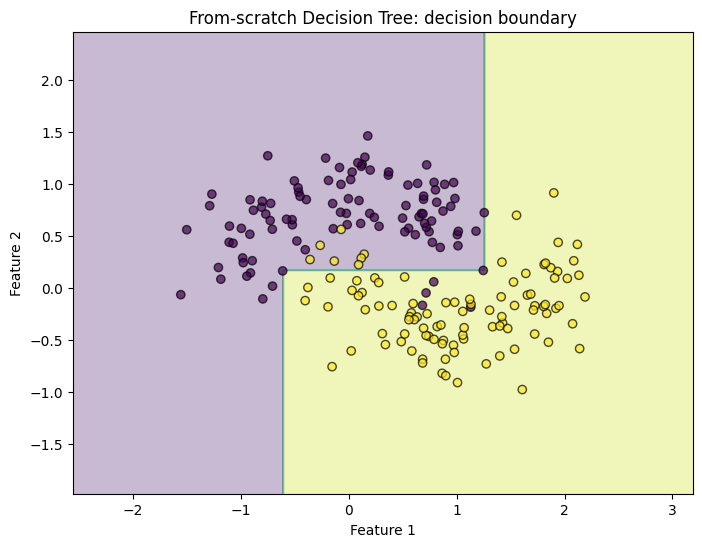

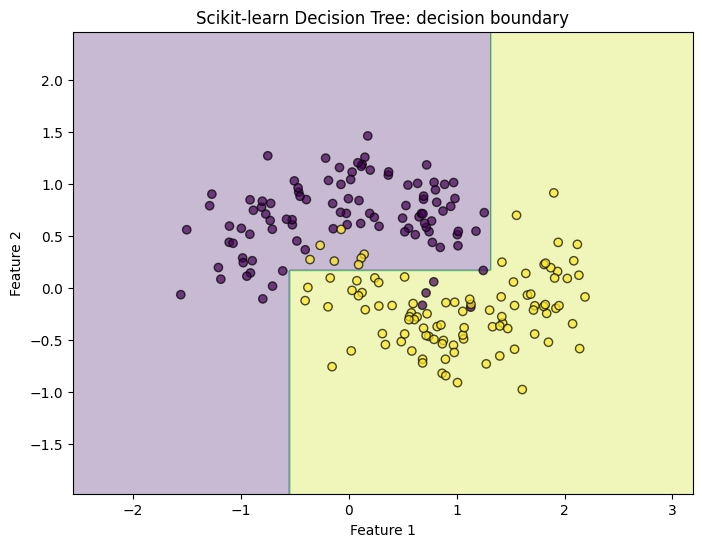

In [10]:
plot_decision_boundary(
    scratch_tree,
    X_test,
    y_test,
    "From-scratch Decision Tree: decision boundary"
)

plot_decision_boundary(
    sklearn_tree,
    X_test,
    y_test,
    "Scikit-learn Decision Tree: decision boundary"
)

## Hyperparameter Sweeps

### Max Depth
It is possible to see that
- small depth -> underfitting
- intermediate depth -> optimal generalization
- large depth -> overfitting

The decision boundary plots of the trees with the optimal `max_depth=7` are much more fragmented than the ones with `max_depth=3`. We can also see small rectangular islands, tiny vertical strips, and tiny corrective regions, a sign that the tree is already memorizing local irregularities in the dataset. Going further than this would lead to overfitting, which is confirmed by the metrics plot.

Finally, even for this more complex tree, the implementation from scratch and the sklearn model are very close, which speaks to the goodness of our model.

In [23]:
depth_values = range(1, 21)
sweep_results = parameter_sweep_trees(
    model_cls=DecisionTree, 
    param_grid={
        'max_depth': depth_values
    }, 
    X_train=X_train, 
    y_train=y_train, 
    X_test=X_test, 
    y_test=y_test, 
    base_params={
        'random_state': 42
    }
)

sweep_df = pd.DataFrame(sweep_results)

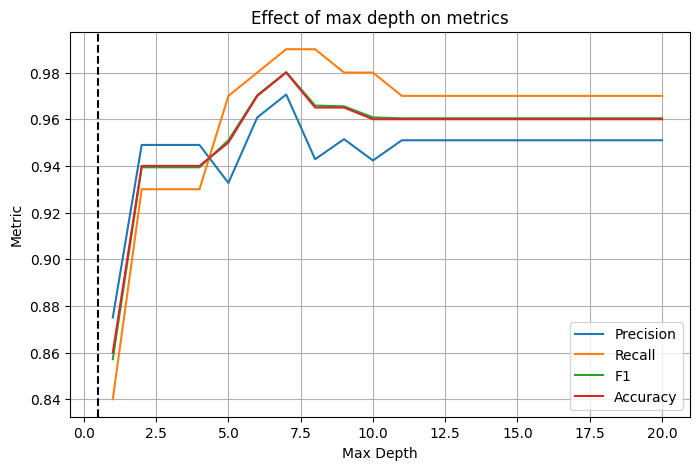

In [24]:
plt.figure(figsize=(8, 5))

plt.axvline(0.5, ymin=0., ymax=1, ls='--', c='k')
plt.plot(sweep_df["max_depth"], sweep_df["test_precision"], label="Precision")
plt.plot(sweep_df["max_depth"], sweep_df["test_recall"], label="Recall")
plt.plot(sweep_df["max_depth"], sweep_df["test_f1"], label="F1")
plt.plot(sweep_df["max_depth"], sweep_df["test_accuracy"], label="Accuracy")

plt.xlabel("Max Depth")
plt.ylabel("Metric")
plt.title("Effect of max depth on metrics")
plt.legend()
plt.grid(True)

plt.show()

In [14]:
best_row = sweep_df.loc[sweep_df["test_f1"].idxmax()]
best_row

max_depth         7.000000
test_accuracy     0.980000
test_precision    0.970588
test_recall       0.990000
test_f1           0.980198
fit_time          0.388368
Name: 6, dtype: float64

In [19]:
scratch_tree_depth_7 = DecisionTree(
    max_depth=7,
    min_samples_split=2,
    random_state=42,
)

scratch_tree_depth_7.fit(X_train, y_train)

sklearn_tree_depth_7 = SklearnDecisionTreeClassifier(
    criterion="entropy",
    max_depth=7,
    min_samples_split=2,
    random_state=42,
)

sklearn_tree_depth_7.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

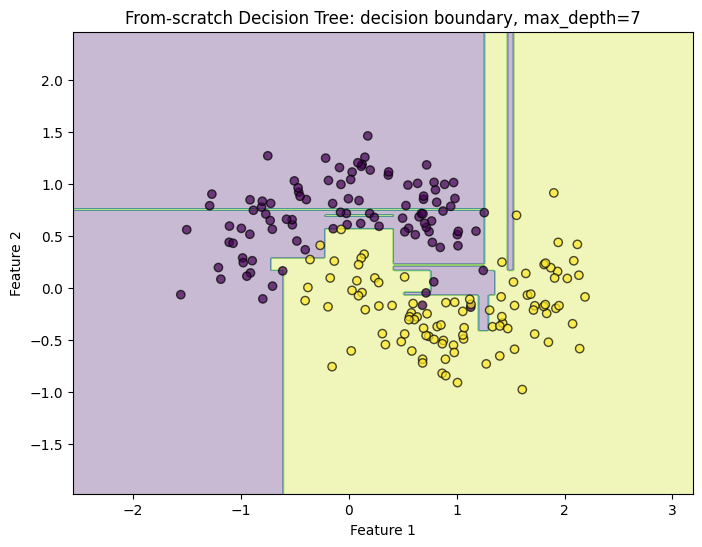

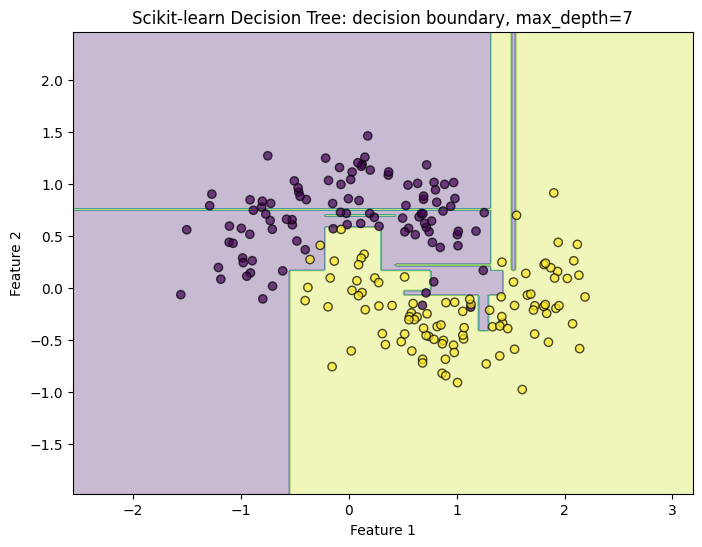

In [20]:
plot_decision_boundary(
    scratch_tree_depth_7,
    X_test,
    y_test,
    "From-scratch Decision Tree: decision boundary, max_depth=7"
)

plot_decision_boundary(
    sklearn_tree_depth_7,
    X_test,
    y_test,
    "Scikit-learn Decision Tree: decision boundary, max_depth=7"
)

In [21]:
scratch_tree_depth_20 = DecisionTree(
    max_depth=20,
    min_samples_split=2,
    random_state=42,
)

scratch_tree_depth_20.fit(X_train, y_train)

sklearn_tree_depth_20 = SklearnDecisionTreeClassifier(
    criterion="entropy",
    max_depth=20,
    min_samples_split=2,
    random_state=42,
)

sklearn_tree_depth_20.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curren

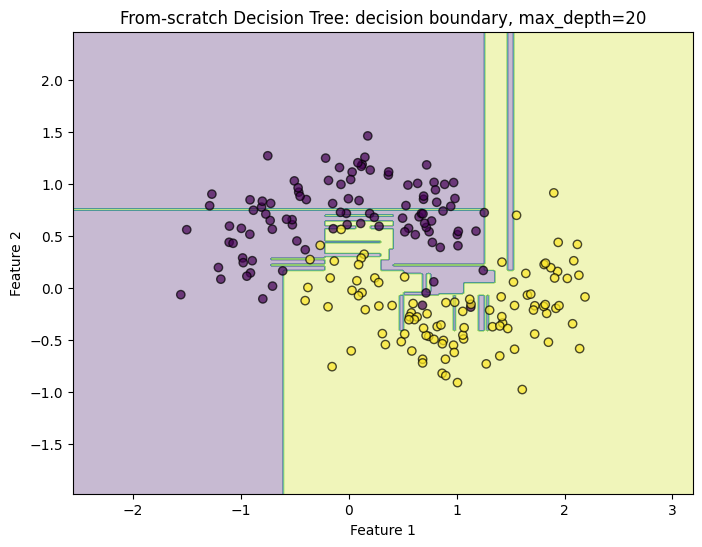

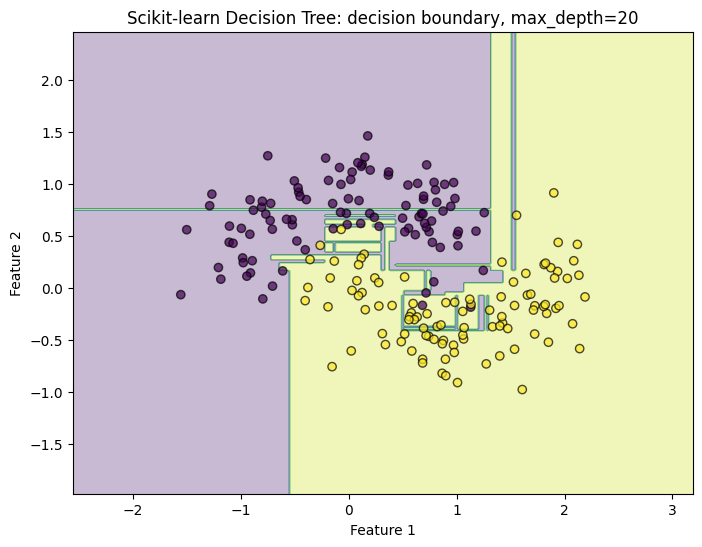

In [22]:
plot_decision_boundary(
    scratch_tree_depth_20,
    X_test,
    y_test,
    "From-scratch Decision Tree: decision boundary, max_depth=20"
)

plot_decision_boundary(
    sklearn_tree_depth_20,
    X_test,
    y_test,
    "Scikit-learn Decision Tree: decision boundary, max_depth=20"
)